In [138]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.ensemble import BalancedRandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight

In [128]:
df = pd.read_csv('D:/PROJECT/NETWORK ANOMALY DETECTION/preprocessed_data.csv')

In [129]:
df.columns

Index(['Unnamed: 0', 'packet_size', 'inter_arrival_time', 'src_port',
       'dst_port', 'packet_count_5s', 'spectral_entropy',
       'frequency_band_energy', 'label', 'protocol_type_TCP',
       'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3',
       'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN',
       'tcp_flags_SYN', 'tcp_flags_SYN-ACK', 'packet_size_log',
       'inter_arrival_time_log', 'packet_count_5s_log', 'spectral_entropy_log',
       'frequency_band_energy_log', 'size_per_packet',
       'inter_arrival_per_packet', 'entropy_minus_energy', 'packet_size.1',
       'inter_arrival_time.1', 'packet_count_5s.1', 'spectral_entropy.1',
       'frequency_band_energy.1', 'packet_size inter_arrival_time',
       'packet_size packet_count_5s', 'packet_size spectral_entropy',
       'packet_size frequency_band_energy',
       'inter_arrival_time packet_count_5s',
       'inter_arrival_time spectral_entropy',
       'inter_arrival_time frequency_band_energy

In [130]:
df.drop('Unnamed: 0', axis=1, inplace=True)


In [131]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,...,packet_size frequency_band_energy,inter_arrival_time packet_count_5s,inter_arrival_time spectral_entropy,inter_arrival_time frequency_band_energy,packet_count_5s spectral_entropy,packet_count_5s frequency_band_energy,spectral_entropy frequency_band_energy,SYN_ACK_ratio,FIN_SYN_ratio,TCP_vs_UDP
0,0.405154,0.620362,62569,443,0.857143,0.834066,0.534891,0.0,0,1,...,0.216713,0.531739,0.517423,0.331826,0.714914,0.458478,0.446134,0.0,0.0,0.0
1,0.527559,0.741288,59382,443,0.785714,0.147196,0.990757,0.0,0,1,...,0.522683,0.582440,0.109114,0.734436,0.115654,0.778452,0.145835,0.0,0.0,0.0
2,0.226199,0.485116,65484,80,0.285714,0.855192,0.031781,0.0,0,1,...,0.007189,0.138605,0.414867,0.015418,0.244341,0.009080,0.027179,0.0,0.0,0.0
3,0.573372,0.450965,51707,53,0.142857,0.153220,0.169958,0.0,0,0,...,0.097449,0.064424,0.069097,0.076645,0.021889,0.024280,0.026041,0.0,0.0,0.0
4,0.651396,0.888740,26915,53,0.714286,0.923916,0.552053,0.0,1,0,...,0.359605,0.634814,0.821121,0.490632,0.659940,0.394324,0.510051,0.0,0.0,1.0


In [132]:
df['label'].value_counts()

label
0.0    900
1.0    100
Name: count, dtype: int64

In [133]:
# overwrite df with the balanced training set (X_train_res + y_res)
df = pd.concat([X_train_res.reset_index(drop=True), y_res.reset_index(drop=True)], axis=1)

# ensure X_train_res exists; if not, try to create it from available variables
try:
    X_train_res
except NameError:
    if 'X_train' in globals():
        X_src = X_train
    elif 'X_train_scaled' in globals():
        arr = X_train_scaled
        # try to recover original column names if X_train dataframe exists
        if 'X_train' in globals() and isinstance(X_train, pd.DataFrame):
            if 'scaler' in globals() and hasattr(scaler, 'inverse_transform'):
                X_src = pd.DataFrame(scaler.inverse_transform(arr), columns=X_train.columns)
            else:
                X_src = pd.DataFrame(arr, columns=X_train.columns)
        else:
            X_src = pd.DataFrame(arr, columns=[f'feat_{i}' for i in range(arr.shape[1])])
    else:
        raise NameError("X_train_res not found and neither X_train nor X_train_scaled are available to resample from.")

    # perform resampling using SMOTE (sm) and y_train
    X_resampled, y_resampled = sm.fit_resample(X_src, y_train)
    X_train_res = pd.DataFrame(X_resampled, columns=X_src.columns)
    y_res = pd.Series(y_resampled, name=y_train.name)

# overwrite df with the balanced training set (X_train_res + y_res)
df = pd.concat([X_train_res.reset_index(drop=True), pd.Series(y_res).reset_index(drop=True)], axis=1)

# ensure label column exists and has correct name/dtype
if 'label' not in df.columns:
    df.rename(columns={df.columns[-1]: 'label'}, inplace=True)
df['label'] = df['label'].astype(y_res.dtype)

# quick check
print("New df shape:", df.shape)
print(df['label'].value_counts())

New df shape: (1440, 43)
label
0.0    720
1.0    720
Name: count, dtype: int64


In [134]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,...,inter_arrival_time packet_count_5s,inter_arrival_time spectral_entropy,inter_arrival_time frequency_band_energy,packet_count_5s spectral_entropy,packet_count_5s frequency_band_energy,spectral_entropy frequency_band_energy,SYN_ACK_ratio,FIN_SYN_ratio,TCP_vs_UDP,label
0,0.728704,0.270799,23794,443,0.785714,0.974842,0.687260,1,0,0,...,0.212771,0.263987,0.186110,0.765948,0.539990,0.669971,0.0,1.0,1.0,0.0
1,0.911954,0.540764,7449,53,0.357143,0.924877,0.386174,1,0,0,...,0.193130,0.500140,0.208829,0.330313,0.137919,0.357163,0.0,0.0,1.0,0.0
2,0.508232,0.906499,47243,443,0.714286,0.752234,0.966165,0,0,0,...,0.647500,0.681900,0.875828,0.537310,0.690118,0.726783,0.0,0.0,0.0,0.0
3,0.108805,0.303314,9099,53,0.142857,0.832162,0.623491,0,0,0,...,0.043331,0.252406,0.189113,0.118880,0.089070,0.518845,0.0,0.0,0.0,0.0
4,0.015748,0.027628,50172,80,0.857143,0.219381,0.028391,1,0,0,...,0.023681,0.006061,0.000784,0.188041,0.024335,0.006228,1.0,0.0,1.0,0.0


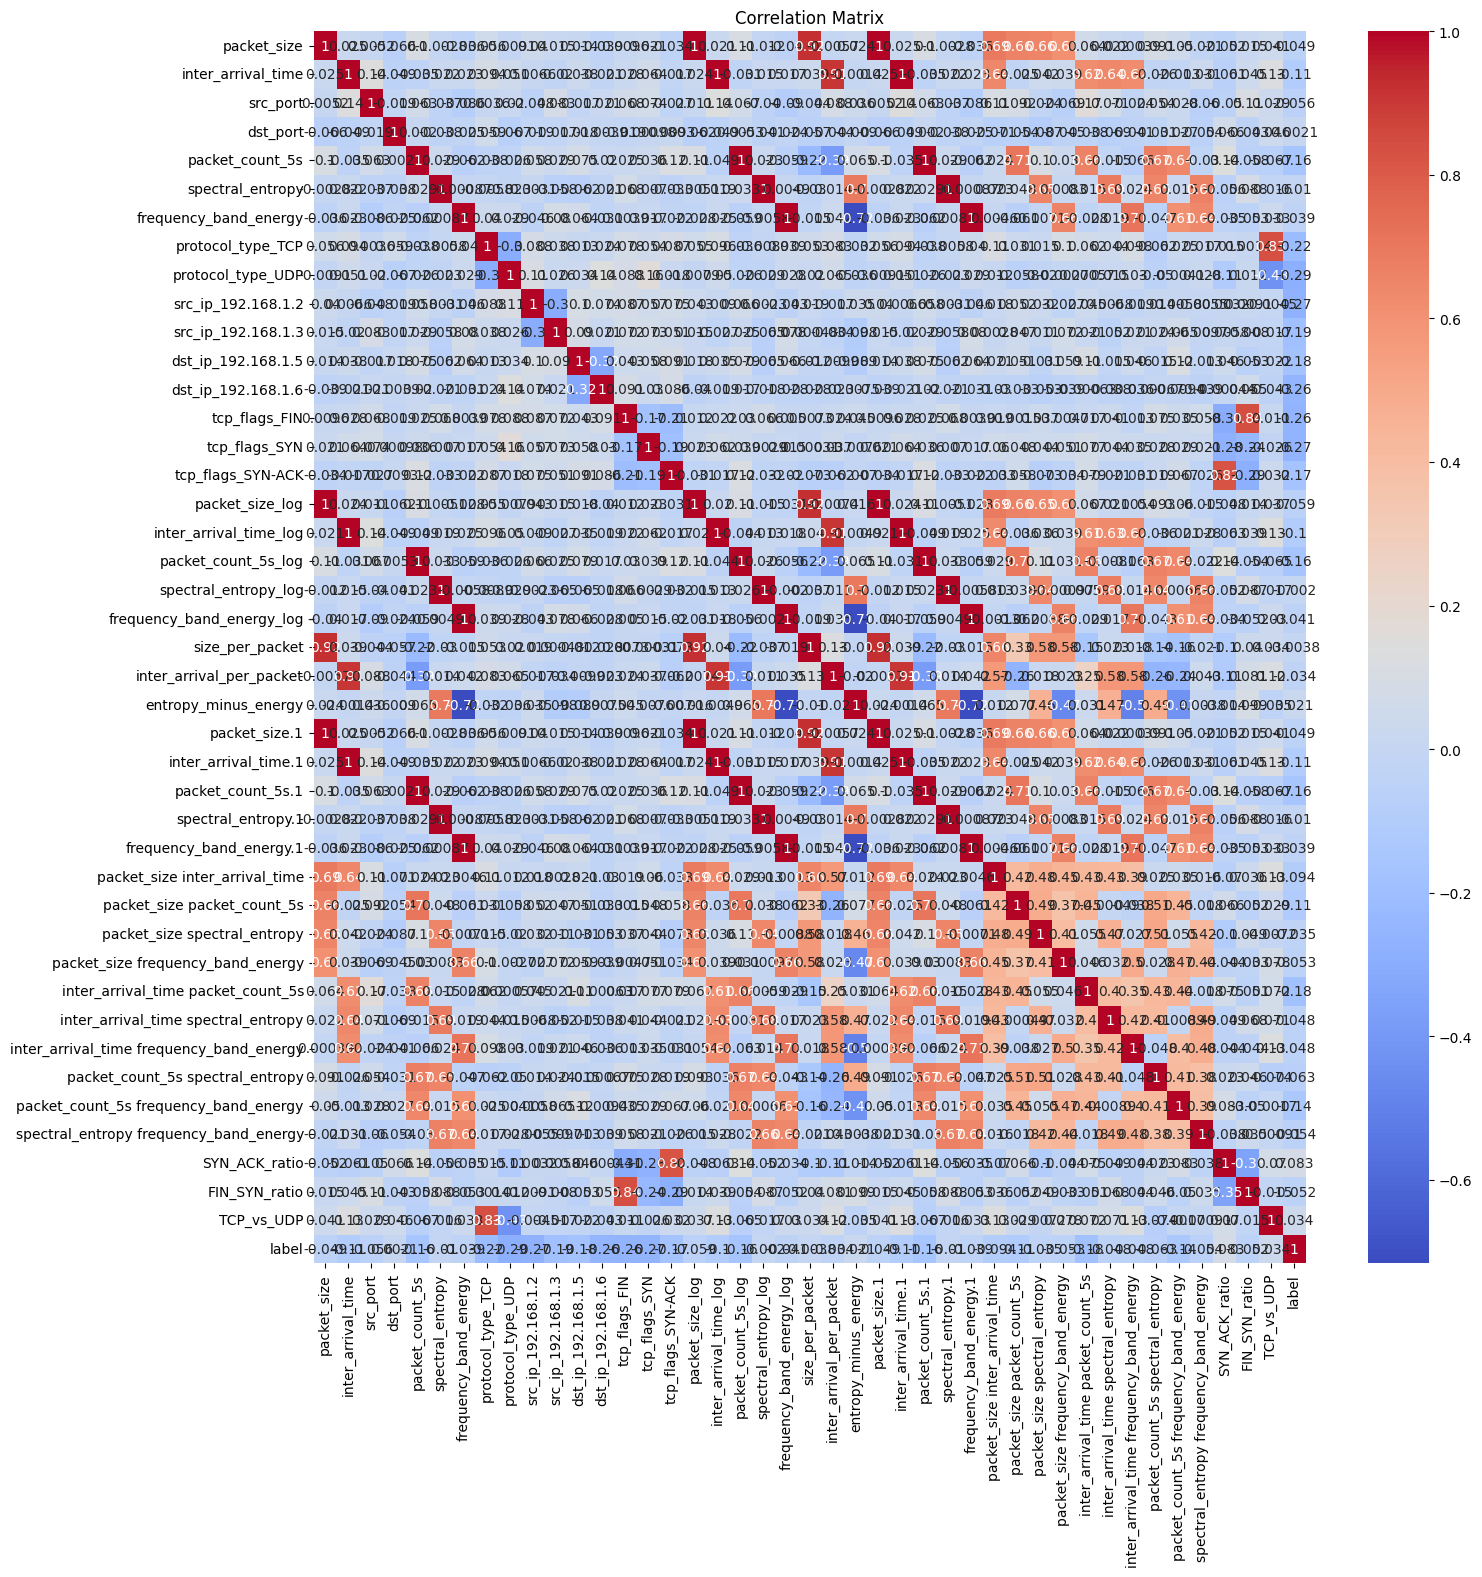

In [141]:
plt.figure(figsize=(16,16))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [142]:
df.describe()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,...,inter_arrival_time packet_count_5s,inter_arrival_time spectral_entropy,inter_arrival_time frequency_band_energy,packet_count_5s spectral_entropy,packet_count_5s frequency_band_energy,spectral_entropy frequency_band_energy,SYN_ACK_ratio,FIN_SYN_ratio,TCP_vs_UDP,label
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,...,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,0.484765,0.491057,31410.909722,196.980556,0.467780,0.488093,0.476906,0.220139,0.238889,0.213194,...,0.226484,0.242245,0.237378,0.234956,0.218224,0.231791,0.286982,0.240550,0.325885,0.500000
std,0.273888,0.251583,18281.636611,163.890304,0.284331,0.264218,0.271718,0.414484,0.426553,0.409706,...,0.202480,0.200066,0.197948,0.208932,0.195954,0.199835,0.413021,0.397934,0.429684,0.500174
min,0.000000,0.000595,1038.000000,53.000000,0.000000,0.002198,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000074,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257793,0.297086,15740.250000,60.000000,0.214286,0.264878,0.257094,0.000000,0.000000,0.000000,...,0.067685,0.085437,0.072108,0.067235,0.065252,0.072037,0.000000,0.000000,0.000000,0.000000
50%,0.475813,0.481574,31064.500000,80.000000,0.435416,0.490567,0.460390,0.000000,0.000000,0.000000,...,0.163525,0.185469,0.181062,0.175470,0.161046,0.182402,0.000000,0.000000,0.000000,0.500000
75%,0.718622,0.675020,46760.250000,410.250000,0.714286,0.700310,0.698409,0.000000,0.000000,0.000000,...,0.329268,0.352861,0.366386,0.341510,0.317460,0.338705,0.692215,0.465596,0.859456,1.000000
max,1.000000,1.000000,65484.000000,443.000000,1.000000,1.000000,0.999485,1.000000,1.000000,1.000000,...,0.962817,0.935101,0.947695,0.971505,0.986927,0.944450,1.000000,1.000000,1.000000,1.000000


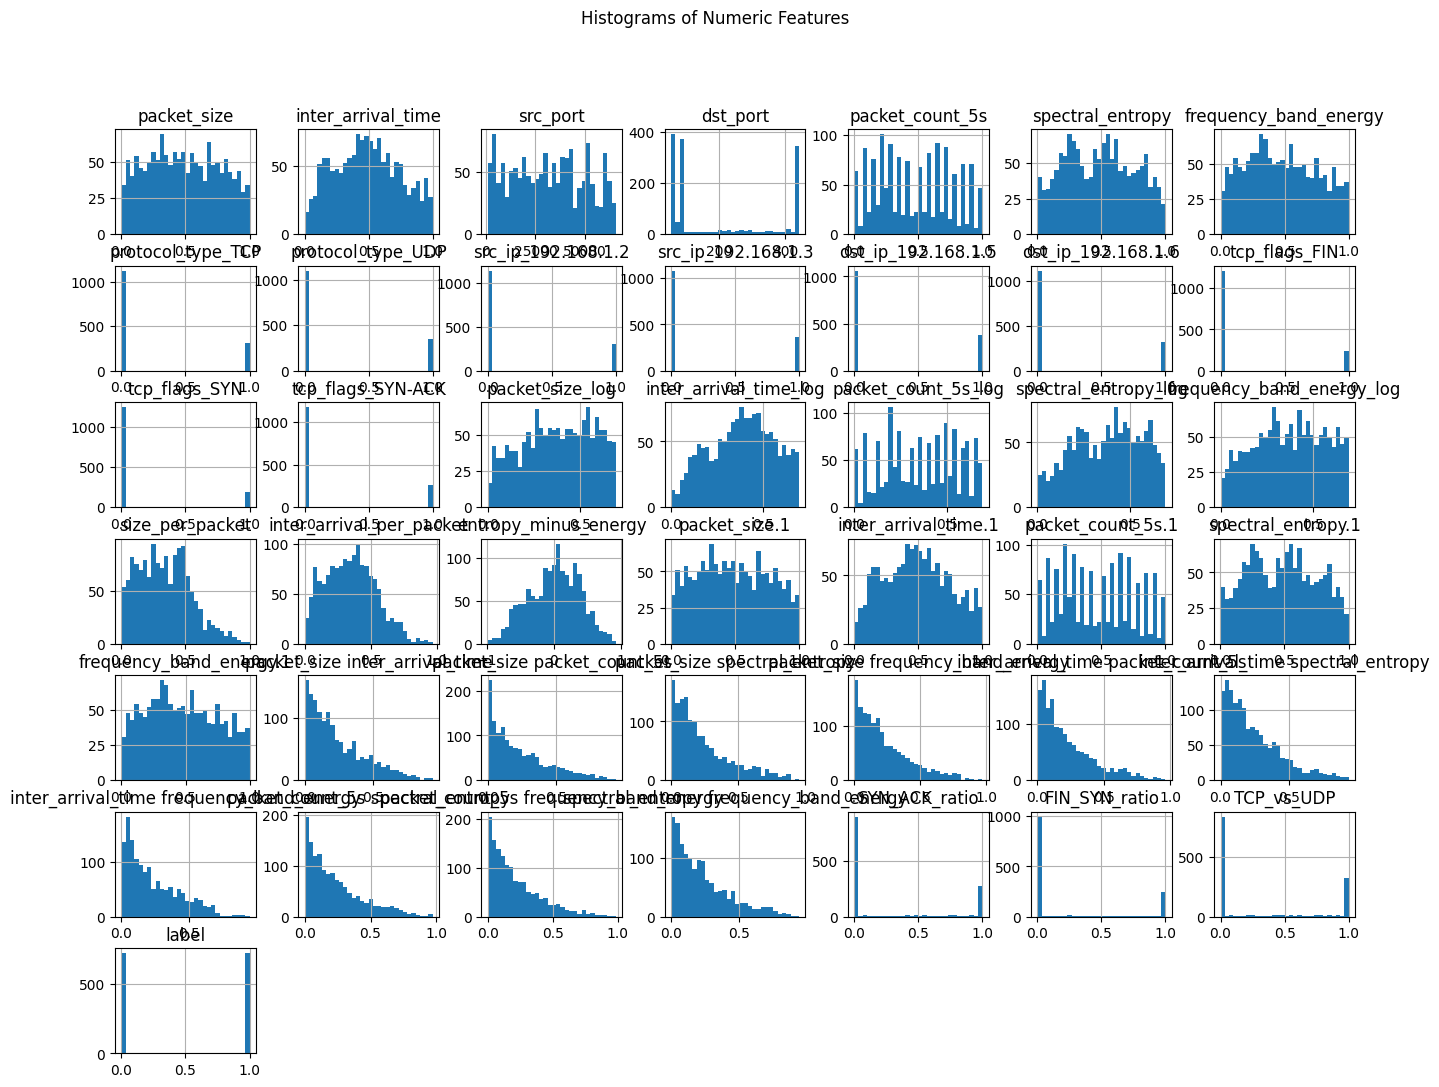

In [143]:
df.hist(figsize=(16,12), bins=30)
plt.suptitle("Histograms of Numeric Features")
plt.show()

In [ ]:
# Train a deep MLP classifier on the balanced training set (uses existing variables)
# Split a validation set, fit a pipeline (scaler + MLP) with class-based sample weights, and evaluate.

# prepare data
X = X_train_res.copy()           # DataFrame of shape (1440, n_features)
y = y_res                        # Series length 1440

In [144]:
# train/validation split (stratified)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# build pipeline re-using existing scaler if desired
pipe = Pipeline([
    ('scaler', scaler),  # uses the StandardScaler() already in the session
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        alpha=0.01,
        learning_rate_init=0.0005,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

# compute sample weights for the training fold using existing class_weights dict
sw_tr = compute_sample_weight(class_weight=class_weights, y=y_tr)

# fit
pipe.fit(X_tr, y_tr, mlp__sample_weight=sw_tr)

# evaluate on validation set
y_val_pred = pipe.predict(X_val)
y_val_proba = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe, "predict_proba") else None

print("Validation classification report:")
print(classification_report(y_val, y_val_pred))
print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))
if y_val_proba is not None:
    print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

Validation classification report:
              precision    recall  f1-score   support

         0.0       0.93      0.66      0.77       180
         1.0       0.15      0.55      0.24        20

    accuracy                           0.65       200
   macro avg       0.54      0.61      0.51       200
weighted avg       0.85      0.65      0.72       200

Confusion matrix:
[[119  61]
 [  9  11]]
Validation ROC AUC: 0.6211111111111111
